In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [178]:
def data_simulation(sample_size, scale, period, variance):

    x = np.random.uniform(-scale, scale, sample_size)
    x.sort()
    noise = np.random.normal(0, variance, sample_size)
    y = x * np.cos(x / period) + noise
    
    return x, y

In [179]:
def scatter_plot(x_train, x_test, y_train, y_test):
    plt.figure(figsize=(15, 5))
    plt.plot(x_train, y_train, '.', color = 'black', markersize = 3, label = 'train')
    plt.plot(x_test, y_test, '.', color = 'red', markersize = 8, label = 'test')

    plt.xlabel('X')
    plt.ylabel('Y')
    leg = plt.legend(loc = 'lower center', fontsize = 'large')
    leg.get_frame().set_alpha(0)
    return plt

In [180]:
def MSE(a, b):
    return ((a - b)**2).mean()

In [181]:
sample_size = 300
variance = 10
scale = 100
period = 6

x_train , y_train = data_simulation(sample_size, scale, period, variance)
x_test , y_test = data_simulation(100, scale, period, variance)

In [182]:
def plot_polynomial_curves(x_train, x_test, y_train, y_test, degree, scale):

    plt = scatter_plot(x_train, x_test, y_train, y_test)

    loss_train_stack, loss_test_stack = [], []
    color = cm.rainbow(np.linspace(0, 1, len(degree)))

    for k, c in zip(range(len(degree)), color):
        coef = np.polyfit(x_train, y_train, degree[k])

        y_hat_train = np.polyval(coef, x_train)
        y_hat_test = np.polyval(coef, x_test)

        loss_train_stack.append(MSE(y_hat_train, y_train))
        loss_test_stack.append(MSE(y_hat_test, y_test))

        print('Polynomial degree: ', degree[k], ' | MSE train:', np.round(loss_train_stack[-1], 4), ' | MSE test:', np.round(loss_test_stack[-1], 4))

        x_draw = np.linspace(-scale, scale, num = 200)
        y_draw = np.polyval(coef, x_draw)

        plt.plot(x_draw, y_draw, color = c, label = degree[k])
        plt.ylim(min(min(y_train), min(y_test)), max(max(y_train), max(y_test)))


    leg = plt.gca().legend(loc='center left', bbox_to_anchor=(1, .65), title="Polynomial degree of  \n  the fitted curve \n")
    leg.get_frame().set_alpha(0)

Polynomial degree:  0  | MSE train: 1907.1195  | MSE test: 1791.6368
Polynomial degree:  1  | MSE train: 1757.7049  | MSE test: 1898.4673
Polynomial degree:  3  | MSE train: 1526.5959  | MSE test: 1748.1388
Polynomial degree:  5  | MSE train: 1243.8758  | MSE test: 1238.4749
Polynomial degree:  10  | MSE train: 923.0542  | MSE test: 951.478
Polynomial degree:  20  | MSE train: 111.7965  | MSE test: 108.742
Polynomial degree:  50  | MSE train: 99.4114  | MSE test: 40668.8547


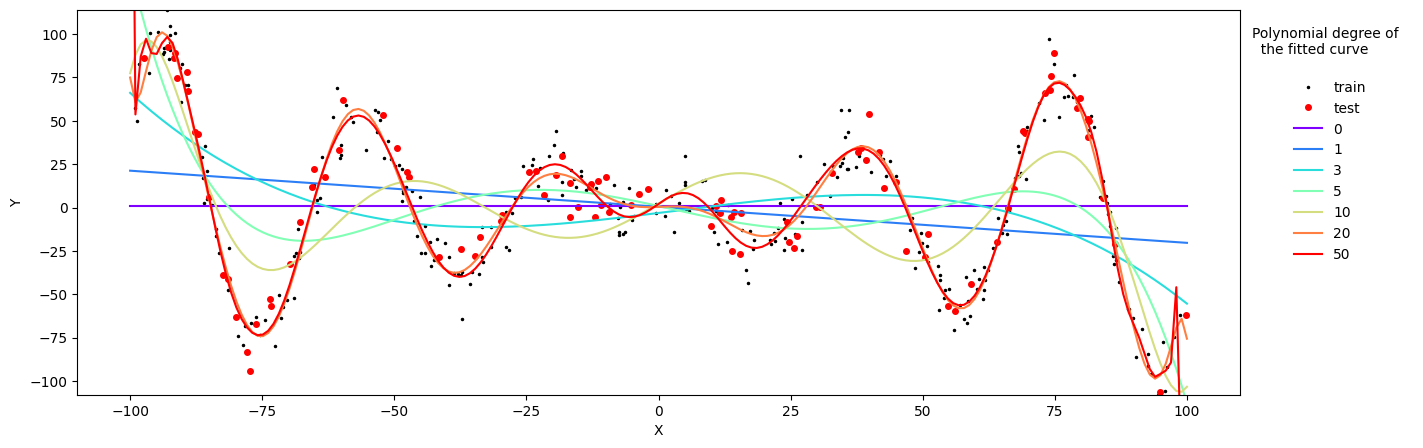

In [183]:
degree = [0, 1, 3, 5, 10, 20, 50]
plot_polynomial_curves(x_train, x_test, y_train, y_test, degree, scale)